---
# Tutoriumsblatt 1: Visualisierung der Aufgaben
SS 2025 – Tutorium: Markovsche Ketten <br>
[Ilias Seite zum Kurs](https://ilias.studium.kit.edu/goto.php?target=crs_2640974&client_id=produktiv) <br>
Dominik Ebert

---

---
## T2 (Zyklische Irrfahrt)
---

## 1. Übgergangswahrscheinlichkeit

In [1]:
import numpy as np

In [2]:
# Implementierung der Übergangsmatrix P
states = np.array([0, 1, 2, 3, 4])
N = len(states)

# P ist eine Numpy-Matrix mit N Zeilen und N Spalten
P = np.zeros((N, N))

# Die Übergangswahrscheinlichkeiten werden in die Matrix P eingetragen
# z.B P[0, 0] = 0.5 
# Die Wahrscheinlichkeit, von einem Zustand i nach (i + 1) mod 5 oder (i − 1) mod 5 zu gelangen, 
# ist hier jeweils 0.5
P[0, 1] = 0.5; P[0, 4] = 0.5
P[1, 0] = 0.5; P[1, 2] = 0.5
P[2, 1] = 0.5; P[2, 3] = 0.5
P[3, 2] = 0.5; P[3, 4] = 0.5
P[4, 3] = 0.5; P[4, 0] = 0.5
# Die Matrix P ist jetzt vollständig definiert
print(P)

[[0.  0.5 0.  0.  0.5]
 [0.5 0.  0.5 0.  0. ]
 [0.  0.5 0.  0.5 0. ]
 [0.  0.  0.5 0.  0.5]
 [0.5 0.  0.  0.5 0. ]]


Wir verwenden die Beziehung

$$
P(X_{n+m} = j | X_m = i) = p^{(n)}_{ij} \quad \text{für alle } i, j \in S, \, m, n \in \mathbb{N}_0, \text{ mit } P(X_m = i) > 0.
$$

Dazu berechnen wir $ P^3 $ ,  um die 3-Schritt-Übergangswahrscheinlichkeiten zu bestimmen. Wir erhalten:

In [3]:
# Die Matrix P^3 wird berechnet
np.linalg.matrix_power(P, 3)

array([[0.   , 0.375, 0.125, 0.125, 0.375],
       [0.375, 0.   , 0.375, 0.125, 0.125],
       [0.125, 0.375, 0.   , 0.375, 0.125],
       [0.125, 0.125, 0.375, 0.   , 0.375],
       [0.375, 0.125, 0.125, 0.375, 0.   ]])

In [4]:
# mit festem Startzustand 1
v = np.array([0, 1, 0, 0, 0]) # Startvektor

# Die Matrix P^3 wird auf den Startzustand x angewendet
x3 = np.dot(v, np.linalg.matrix_power(P, 3))
print(x3)

[0.375 0.    0.375 0.125 0.125]


Kommentar: Dies entspricht gerade der 2. Zeile ($\hat{=} 1$, da Index bei 0 beginnend) der Matrix $P^3$

Im Folgenden visualisieren wir uns die n-Schritt-Übergangswahrscheinlichkeiten vom Startzustand 1.

In [5]:
import matplotlib.pyplot as plt

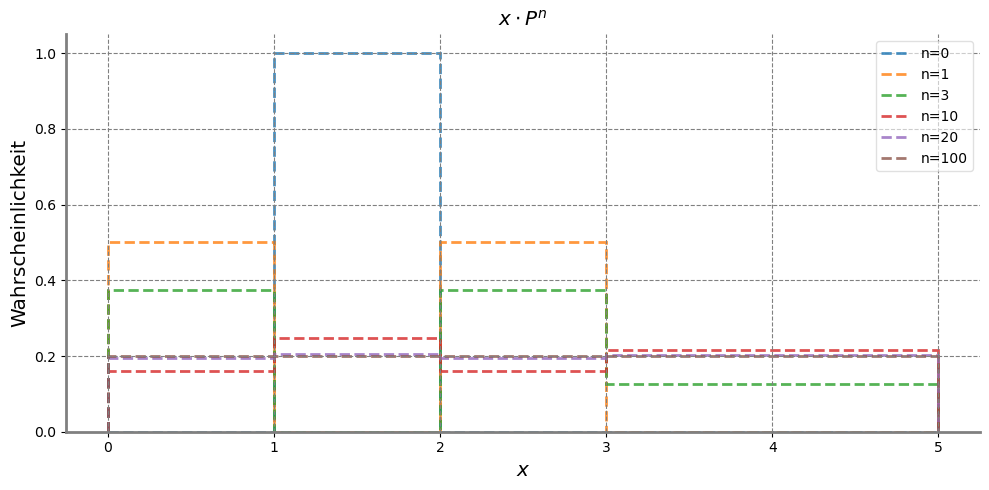

In [6]:
# Werte für n
n_values = [0, 1, 3, 10, 20, 100]

# Bereich für die x-Achse
x_range = np.linspace(0, 5, 100)

# Plot erstellen
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True, linestyle='--', color='grey')
ax.set_axisbelow = False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Plotten von P^n * x für verschiedene n
for n in n_values:
    result = np.dot(v, np.linalg.matrix_power(P, n))
    ax.stairs(result, label=f"n={n}", alpha=0.8, fill=False, linewidth=2, linestyle='--')

# Legende und Achsentitel
legend = ax.legend(fontsize="medium", markerscale=1, framealpha=0.6, loc="upper right")
ax.set_xlabel('$x$', fontsize='x-large')
ax.set_ylabel('Wahrscheinlichkeit', fontsize='x-large')
ax.set_title('$x \cdot P^n$', fontsize='x-large')
plt.tight_layout()
plt.show()

## 2. Visualisierung 

In [17]:
import matplotlib.animation as animation

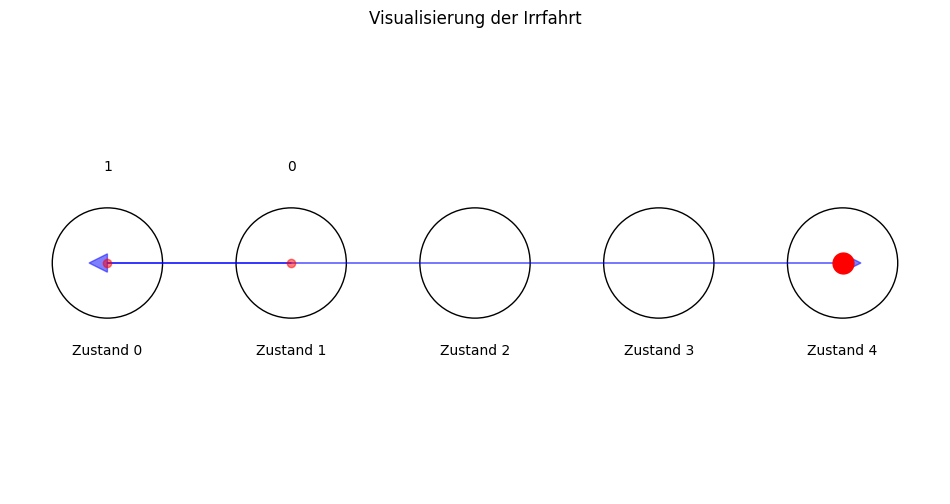

In [37]:
def create_random_walk_visualization(steps=10):
    # Figure und Axis erstellen
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Positionen der Zustände
    state_positions = np.array([(i, 0) for i in range(N)])
    
    # Startposition (Zustand 1)
    current_state = 1
    path = [current_state]
    
    # Zufällige Schritte generieren
    for _ in range(steps):
        next_state = np.random.choice(states, p=P[current_state])
        path.append(next_state)
        current_state = next_state
    
    # Visualisierung
    # Kreise für die Zustände zeichnen
    for i in range(N):
        circle = plt.Circle(state_positions[i], 0.3, fill=False)
        ax.add_patch(circle)
        ax.text(i, -0.5, f'Zustand {i}', ha='center')
    
    # Pfeile für die Übergänge zeichnen
    for i in range(len(path)-1):
        start = state_positions[path[i]]
        end = state_positions[path[i+1]]
        ax.arrow(start[0], start[1], 
                end[0]-start[0], end[1]-start[1],
                head_width=0.1, head_length=0.1, 
                fc='blue', ec='blue', alpha=0.5)
        
        # Schrittnummer über der Position
        ax.text(path[i], 0.5, str(i), ha='center')
    
    # Aktuelle Position markieren
    ax.plot(path, [0]*len(path), 'ro', alpha=0.5)
    ax.plot(path[-1], 0, 'ro', markersize=15)  # Letzte Position größer
    
    # Achsen anpassen
    ax.set_xlim(-1, N)
    ax.set_ylim(-1.5, 1.5)
    ax.axis('equal')
    ax.axis('off')
    
    plt.title('Visualisierung der Irrfahrt')
    return fig

fig_static = create_random_walk_visualization(steps=2)

In [38]:
def create_random_walk(steps=10):
    
    # Positionen der Zustände
    state_positions = np.array([(i, 0) for i in range(N)])
    
    # Startposition (Zustand 1)
    current_state = 1
    path = [current_state]
    
    # Zufällige Schritte generieren
    for _ in range(steps):
        next_state = np.random.choice(states, p=P[current_state])
        path.append(next_state)
        current_state = next_state
    
    return path

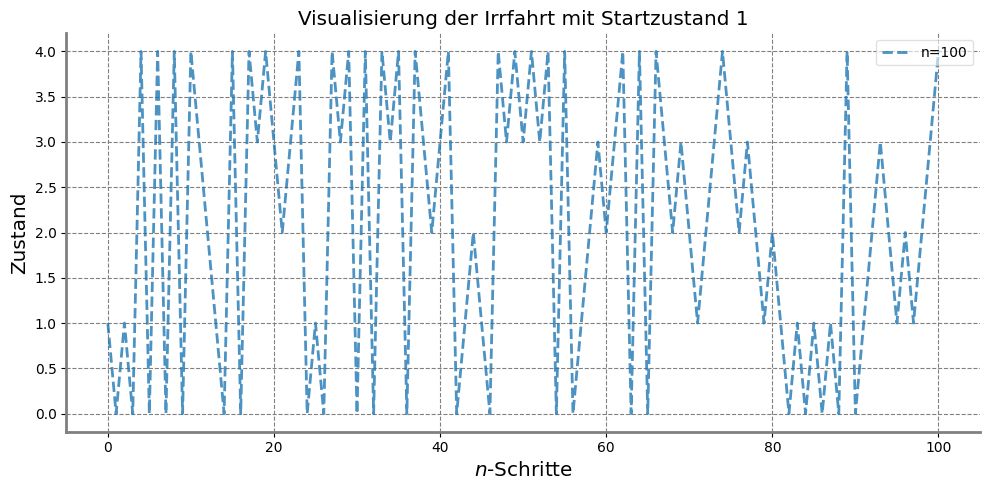

In [45]:
# Statische Visualisierung erstellen
steps = 100
path = create_random_walk(steps=steps)

# Bereich für die x-Achse
x_steps = np.linspace(0, steps, steps+1)

# Plot erstellen
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True, linestyle='--', color='grey')
ax.set_axisbelow = False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)


ax.plot(x_steps, path, label=f"n={n}", alpha=0.8, linewidth=2, linestyle='--')

# Legende und Achsentitel
legend = ax.legend(fontsize="medium", markerscale=1, framealpha=0.6, loc="upper right")
ax.set_xlabel('$n$-Schritte', fontsize='x-large')
ax.set_ylabel('Zustand', fontsize='x-large')
ax.set_title('Visualisierung der Irrfahrt mit Startzustand 1', fontsize='x-large')
plt.tight_layout()
plt.show()

---
## Ausblick: Reinforcement Learning OpenAI Gym TAXI 
---
https://www.itiv.kit.edu/60_LAMA.php

## 1. Fundamentals
Let's start by having a quick look at our very basic game example, which will accompany us on our way to understand the basic concepts of reinforcement learning! 

We'll be using the 'Taxi-v3' environment for this tutorial.

You'll need to install OpenAI Gym:

    pip install gym


In [11]:
import gym

In [12]:
# Run this cell to reset the game

controls = {
    'south': 0,
    'north': 1,
    'east': 2,
    'west': 3,
    'pickup': 4,
    'drop off': 5
}

score = 0

env = gym.make('Taxi-v3', render_mode="ansi") # specify render_mode="ansi" instead of: gym.make('Taxi-v3') 
env.reset()
print(env.render())

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




There are four designated locations in the grid world indicated by R(ed), B(lue), G(reen), and Y(ellow). When the episode starts, the taxi (yellow rectangle) starts off at a random square and the passenger is at a random location (blue colored letter). The taxi drive to the passenger's location, pick up the passenger (green rectangle), drive to the passenger's destination (purple colored letter), and then drop off the passenger. Once the passenger is dropped off, the episode ends.

Run the cell below to play the game manually. You have to run it for each action. The possible commands are:
* south
* north
* east
* west
* pickup
* drop off

## 1.1 General Framework

The general framework can be described as follows (also refer to the illustration below):
  
> 1. At time $t$, the **agent** makes the decision on which **action** $A_t$ to take, based on the **reward** $R_t$ and the **observed enviroment** $O_t$.
>
> 2. Upon recieving the action $A_t$, the **enviroment** gives the next observation $O_{t+1}$ and reward $R_{t+1}$ to the agent.
>
> 3. As objective of the agent is to maximize total future reward, the agent may have to sacrifice immediate reward to gain a larger long-term reward. 

<div align="center">
<img src = "pictures\RL-framework.png"  width="600">
</div>

_(Diagram credit:Sutton, R. S. and Barto, A. G. Introduction to Reinforcement Learning)_

- observation: an environment-specific object representing your observation of the environment. For example, pixel data from a camera, joint angles and joint velocities of a robot, or the board state in a board game line Taxi.

- Action: the input the agent provides to the environment. What is the meaning of the actions? For the deep learning algorithm it should not matter, it should sort it out independent of the meaning of the action. But for us it is handy to have the description, so we can understand the actions.

- State: This represents the board state of the game and in gym returned it is returned as observation. State: a numeric representation of what the agent is observing at a particular moment of time in the environment.

- reward: amount of reward achieved by the previous action. This has always a immediate cause effect relation to the action done in a specific state. Usually it is desirable to maximize the reward over the whole lifetime of the agent. In that case we speak about value and each Reinforcement model also takes a value function into account, which sometimes enables the agent to perform an action, which yields a smaller immediate reward, but a bigger long term value!

## 1.2. Markov Decision Process (MDP)

The Taxi game is an example of an Markov decision process . The game can be described in states, possible actions in a state (leading to a next state with a certain probability) with a reward.

The word Markov refers to Markovian property which means that the state is independent of any previous states history, not on the sequence of events that preceded it. The current state encapsulates all that is needed to decide the future actions, no memory needed.

In terms of this Reinforcement Learning problem the Environment is modelled as a markov model and the agent needs to take actions in this environment to maximize the amount of reward. Since the agent sees only the outside of the environment (the effects of it actions) it is often referred to as the hidden markov model which needs to be learnt.

## 1.3 Policy

Policy (π): The strategy that the agent employs to determine next action 'a' in state 's'. Note that it does not state if it is a good or bad policy, it is a policy. The policy is normally noted with the greek letter π. Optimal policy (π*), policy which maximizes the expected reward. Among all the policies taken, the optimal policy is the one that optimizes to maximize the amount of reward received or expected to receive over a lifetime.

So how do we find the optimal policy (π*) that is maximize our value (and win the game) given the Taxi environment with the Markov model .

Stable Baselines3 RL tutorial:

https://github.com/araffin/rl-tutorial-jnrr19?tab=readme-ov-file

https://colab.research.google.com/github/araffin/rl-tutorial-jnrr19/blob/sb3/1_getting_started.ipynb